In [1]:
from typing import Union
import matplotlib.pyplot as plt
from typing import Sequence
import re

def parse_xml_array(text: str):
    '''
    Parse XML array listings which has one entry per line.
    '''
    lines = text.split('\n')
    ret: list[float] = []
    for line in lines:
        line = line.strip()
        if line == '':
            continue
        assert line.startswith('<item>') and line.endswith('</item>')
        ret.append(float(line[6:-7].strip()))
    return ret

def parse_oplus_levels(text: str):
    '''
    Parse ColorOS brightness level listings which has one level per line.
    '''
    lines = text.split('\n')
    ret: list[list[float]] = []
    for line in lines:
        line = line.strip()
        if line == '':
            continue
        assert line.startswith('<level>') and line.endswith('</level>')
        ret.append([float(t) for t in line[7:-8].strip().split(',')])
    return ret

def parse_dts_int(num_str: str):
    if num_str.startswith('0x'):
        return int(num_str[2:], 16)
    return int(num_str, 10)
def parse_dts_listing(raw_str: str):
    ret: list[list[int]] = []
    values_re = re.compile(r'<([^<>]+)>')
    for matcher in values_re.finditer(raw_str):
        values_str = matcher.group(1)
        values = [ parse_dts_int(value) for value in values_str.split(' ') if value != '' ]
        ret.append(values)
    return ret

def make_xml_array(values: Sequence[Union[int, float]], indent=''):
    '''
    Create XML array listing which has one entry per line.
    '''
    ret = ''
    for value in values:
        ret += f'{indent}<item>{value}</item>\n'
    return ret

def make_displayconfig_levels(levels: Sequence[Sequence[Union[int, float]]], level_tag: str, value_tags: Sequence[str], indent=''):
    ret_text = ''
    for level in levels:
        assert len(level) == len(value_tags)
        ret_text += indent
        ret_text += f'<{level_tag}>'
        for value, value_tag in zip(level, value_tags):
            ret_text += f'<{value_tag}>{value}</{value_tag}>'
        ret_text += f'</{level_tag}>'
        ret_text += "\n"
    return ret_text

In [2]:
import bisect
import math

def linear_map(val: float, src: Sequence[float], dst: Sequence[float]):
    '''
    Map the given value using the mapping defined by the two lists,
    interpolated using the linear approach.
    The src list must be non-decreasing.
    '''
    assert len(src) == len(dst)
    lower_bound = bisect.bisect_left(src, val)
    upper_bound_incl = bisect.bisect_right(src, val) - 1
    if upper_bound_incl < 0 or lower_bound >= len(src):
        raise ValueError(f'Value {val} out of bounds [{src[0]}, {src[-1]}]')
    if lower_bound > upper_bound_incl:
        # Value between two points
        ratio = (val - src[upper_bound_incl]) / (src[lower_bound] - src[upper_bound_incl])
        return dst[upper_bound_incl] + (dst[lower_bound] - dst[upper_bound_incl]) * ratio
    else:
        # Value lays on a segment, pick median
        return (
            dst[math.floor((lower_bound + upper_bound_incl) / 2)] +
            dst[math.ceil((lower_bound + upper_bound_incl) / 2)]
        ) / 2

## Source data

Below is brightness metrics from
- `coloros14`: Stock (brightness map could be inaccurate since inaccuracy won't fatally affect UX on stock; no auto brightness info),
- `coloros16_port`: ColorOS port (brightness map could be inaccurate since inaccuracy won't fatally affect UX on stock; no auto brightness info),
- `lineageos`: LineageOS official (auto brightness is known to be way too bright),
- `crdroid`: crDroid OnePlus 8T device tree (auto brightness works but does not work well),
- `fod_opacity`: the stock fingerprint mode dim layer opacities (must be mostly accurate for brightness to match well between normal and fingerprint mode; brightness map can be derived from opacities; no auto brightness info).

LineageOS and crDroid profiles only cover sustainable brightness range, as both officially disable
auto-HBM completely for some reason.

Note that crDroid's brightness map defines the sustainable maximum to be 1100nit (obviously incorrect),
we normalize to make the maximum nits of the auto brightness curve to 500nit.

Stock fingerprint mode dim layer opacities has been slightly edited to address mismatches between
normal and fingerprint mode when register value is below 9 (the minimum value allowed by stock is 9,
but we want to allow as low as 4 in our distribution), as well as two obvious mismatch points above 9.

Terms:

- ui: Engineering UI brightness value, only on ColorOS/OxygenOS.
- lux: Value reported by ambient light sensor.
- nit: The physical brightness value, used as a standard intermediary metric for communicating brightness.
- opacity: Fingerprint mode dim (black) layer opacity. The nit ratio achieved by a specified opacity can be
  calculated as: `(1 - opacity/255) ** 2.2`, where `2.2` is sRGB gamma value.
- register: The value stored in `/sys/class/backlight/panel0-backlight/brightness`.
  For our panel, the sustainable non-HBM range is from 1 to 2047 (0 is completely black),
  and the HBM (High Brightness Mode) range is from 2048 to 4095.
- brightness or backlight: Register divided by its HBM maximum.
- lv255: Legacy backlight value used only in framework-res config. Can describe non-HBM brightness levels only. Valid range from 1 to 255. `lv255 = 1 + backlight * 254`
- lv255sus: Legacy backlight value, but 255 incorrectly corresponds to sustainable max instead of HBM max.

In [3]:
I_USABLE_MIN = 0
I_STOCK_MIN = 1
I_SUSTAINABLE_MAX = 2
I_HBM_MAX = 3
key_registers = [ 4, 9, 2047, 4095 ]
def lv255_to_register(value: float):
    return (value - 1) / 254 * key_registers[I_HBM_MAX]
def lv255sus_to_register(value: float):
    return (value - 1) / 254 * key_registers[I_SUSTAINABLE_MAX]
def register_to_lv255(value: float):
    return 1 + value / key_registers[I_HBM_MAX] * 254
def register_to_backlight(value: float):
    return value / key_registers[I_HBM_MAX]
def backlight_to_register(value: float):
    return value * key_registers[I_HBM_MAX]

# The COS port levels file is in manual mapping mode, and item[1] reflects actual register values
cosp_panel_levels = parse_oplus_levels(open('./data/coloros16_port/panel_levels.txt', 'r').read())
cosp_panel_uis = [ item[0] for item in cosp_panel_levels ]
cosp_panel_registers = [ item[1] for item in cosp_panel_levels ]
cosp_panel_nits = [ item[2] for item in cosp_panel_levels ]
def ui_to_register(value: float):
    return linear_map(value, cosp_panel_uis, cosp_panel_registers)

# The stock COS levels file is in smooth mode, and item[1] does not reflect actual register values
cos_panel_levels = parse_oplus_levels(open('./data/coloros14/panel_levels.txt', 'r').read())
cos_panel_uis = [ item[0] for item in cos_panel_levels ]
cos_panel_nits = [ item[2] for item in cos_panel_levels ]
cos_panel_nits_max = max(*cos_panel_nits)
# We convert ui values to register values them in accordance to the COS port file
cos_panel_registers = [ ui_to_register(v) for v in cos_panel_uis ]

los_panel_lv255suss = parse_xml_array(open('./data/lineageos/panel_lv255s.txt', 'r').read())
los_panel_nits = parse_xml_array(open('./data/lineageos/panel_nits.txt', 'r').read())
los_auto_luxs = [0, *parse_xml_array(open('./data/lineageos/auto_luxs.txt', 'r').read())]
los_auto_nits = parse_xml_array(open('./data/lineageos/auto_nits.txt', 'r').read())
los_panel_nits_max = max(*los_panel_nits)
# We convert lv255s to registers with the formula
los_panel_registers = [ lv255sus_to_register(v) for v in los_panel_lv255suss ]

crd_panel_lv255suss = parse_xml_array(open('./data/crdroid/panel_lv255s.txt', 'r').read())
crd_panel_nits = parse_xml_array(open('./data/crdroid/panel_nits.txt', 'r').read())
crd_auto_luxs = [0, *parse_xml_array(open('./data/crdroid/auto_luxs.txt', 'r').read())]
crd_auto_nits = parse_xml_array(open('./data/crdroid/auto_nits.txt', 'r').read())
crd_panel_nits_max = max(*crd_panel_nits)
# We convert lv255s to registers with the formula
crd_panel_registers = [ lv255sus_to_register(v) for v in crd_panel_lv255suss ]
# Max nit correction
crd_panel_nits = [v / crd_panel_nits_max * los_panel_nits_max for v in crd_panel_nits]
crd_auto_nits = [v / crd_panel_nits_max * los_panel_nits_max for v in crd_auto_nits]

fod_dts_levels = parse_dts_listing(open('./data/fod_opacity/dts.txt', 'r').read())
fod_panel_registers = [ v[0] for v in fod_dts_levels ]
fod_panel_opacitys = [ v[1] for v in fod_dts_levels ]
# Derive nits from opacitys (assuming stock COS HBM maximum nit is right)
fod_panel_nits = [ cos_panel_nits_max * (1 - v/255)**2.2 for v in fod_panel_opacitys ]

## Construct brightness map

This step constructs brightness map which describes the backlight-to-nit mapping.

The mapping can be derived from all the five sources we have.
Among them, we should mostly trust `fod_opacity` since this is the only one whose significant inaccuracies could
fatally damanage user experience on stock.

It can be observed that the correct brightness map is probably piecewise linear. We use the fod_opacity map directly as our final brightness map.

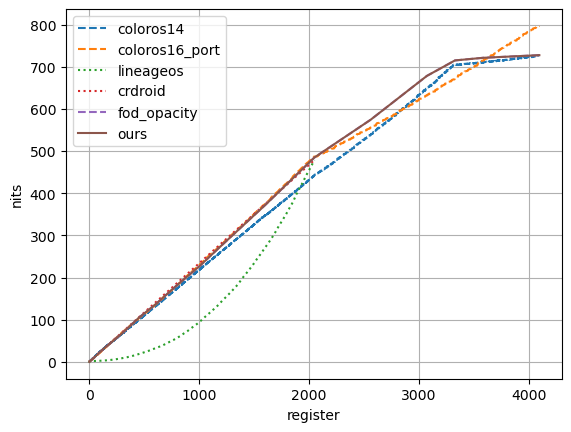

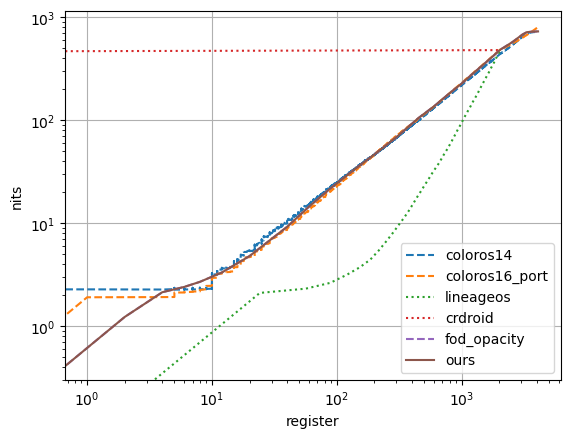

In [4]:
panel_registers = fod_panel_registers
panel_nits = fod_panel_nits

def plot_brightness_maps():
    plt.plot(cos_panel_registers, cos_panel_nits, label='coloros14', linestyle='--')
    plt.plot(cosp_panel_registers, cosp_panel_nits, label='coloros16_port', linestyle='--')
    plt.plot(los_panel_registers, los_panel_nits, label='lineageos', linestyle='dotted')
    plt.plot(crd_panel_registers, crd_panel_nits, label='crdroid', linestyle='dotted')
    plt.plot(fod_panel_registers, fod_panel_nits, label='fod_opacity', linestyle='--')
    plt.plot(panel_registers, panel_nits, label='ours')

    plt.xlabel('register')
    plt.ylabel('nits')
    plt.grid()
    plt.legend()

plot_brightness_maps()
plt.show()
plot_brightness_maps()
plt.xscale('log')
plt.yscale('log')
plt.show()

Calculate nits for key points.

In [5]:
def register_to_nit(val: float):
    return linear_map(val, panel_registers, panel_nits)
def backlight_to_nit(val: float):
    return register_to_nit(backlight_to_register(val))
def nit_to_register(val: float):
    return linear_map(val, panel_nits, panel_registers)
def nit_to_backlight(val: float):
    return register_to_backlight(nit_to_register(val))
key_nits = [ register_to_nit(register) for register in key_registers ]

print(key_registers, key_nits)

[4, 9, 2047, 4095] [2.1330104862470782, 2.8462767128494475, 484.543055188395, 727.41437]


## Create auto brightness mapping

This step construct a reasonable lux-to-nit auto brightness mapping.

Our reference could only come from `lineageos` or `crdroid`. Plot and observe.

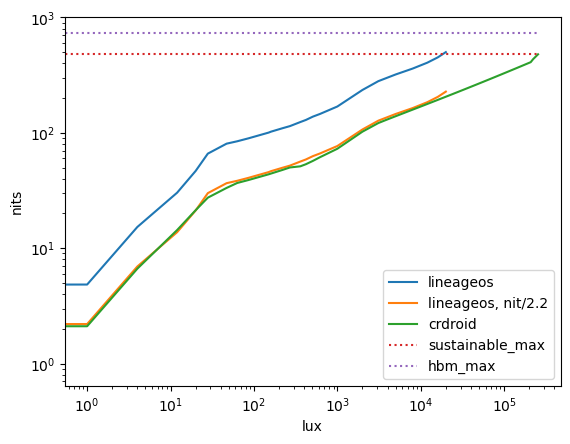

In [6]:
crd_auto_nits_max = max(*crd_auto_nits)
los_auto_nits_max = max(*los_auto_nits)

plt.plot(los_auto_luxs, los_auto_nits, label='lineageos')
plt.plot(los_auto_luxs, [ v/2.2 for v in los_auto_nits], label='lineageos, nit/2.2')
plt.plot(crd_auto_luxs, crd_auto_nits, label='crdroid')

plt.plot(crd_auto_luxs, [ key_nits[I_SUSTAINABLE_MAX] for v in crd_auto_luxs ], label='sustainable_max', linestyle='dotted')
plt.plot(crd_auto_luxs, [ key_nits[I_HBM_MAX] for v in crd_auto_luxs ], label='hbm_max', linestyle='dotted')

plt.xscale('log')
plt.yscale('log')
plt.xlabel('lux')
plt.ylabel('nits')
plt.legend()

Their shapes are very similar. The only problem is that the `lineageos` curve is higher. This matches the observation that `lineageos` curve is way too bright while `crdroid` works (although not well).

But curiously, in theory, the LineageOS brightness curve is more reasonable. On a sunny day, the ambient light value should be around the magnitude of $2 \times 10^4$ lux, and the brightness should reach sustainable max in this case. On the other hand, the seemingly working `crdroid` curve reaches sustainable max at about $2.5 \times 10^5$ lux.

Through comparison, it can be found that the lux readings from LineageOS and stock differs wildly (the former is way higher).
It seems that a resonable behavior (reasonable magnitude, no instability or discontinuity)
can be achieved by changing the kernel device tree sensor config
(`/kernel/oneplus/sm8250/arch/arm64/boot/dts/vendor/oplus/lemonades/kona-sensor.dtsi`).

Then, according to LineageOS and crDroid curves and real experiments, we make an ideal curve
function (which is almost piecewise linear in logarithm space) and use it as our auto brightness curve.

Finally, it can be found by experiment that the maximum extra reading (after changing the kernel config)
contributed by "reflection" when the screen is displaying white under max sustainable brightness 
and moderate ambient light is approximately 30 lux.

We must prevent our auto brightness lux-nits urve from intersecting with the self-reflex lux-nit line,
since this can completely prevent the screen brightness from going down to zero even in an ideal dark room.
Ideally the self-reflex lux-nit line should be far above our curve to make auto brightness adequately consistent
between bright and dark mode UI.
Hence we sometimes need to do the `p_sum` between our ideal function and the self-reflex curve in some settings to enforce that.

Ideal curve max: (50000, 727.414328353416)
Ideal curve max: (50000, 727.4143258701288)


/tmp/ipykernel_23879/2339311334.py:123: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(0, key_nits[I_HBM_MAX])


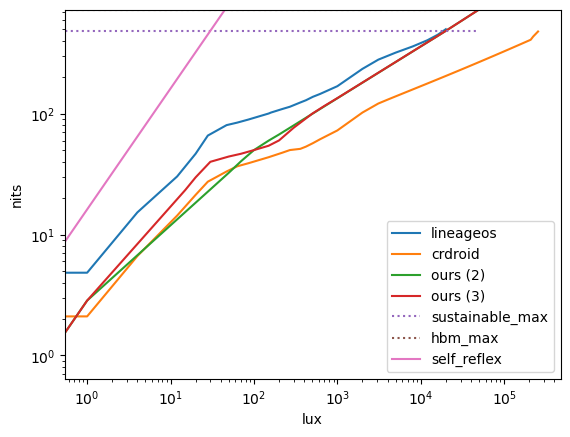

In [7]:
from math import exp, isclose, log
from typing import Sequence, Tuple
import math

sr_sustainable_max_lux = 30
def self_reflex_lux_to_nit(value: float):
    return value / sr_sustainable_max_lux * key_nits[I_SUSTAINABLE_MAX]
def self_reflex_nit_to_lux(value: float):
    return value * sr_sustainable_max_lux / key_nits[I_SUSTAINABLE_MAX]

def p_sum(a, b, p):
    if isclose(a, 0) or isclose(b, 0):
        return min(a, b)
    return ((a ** p + b ** p)) ** (1/p)

def log_piecewise_linear(item: float, ease_sigma: float, *points: Tuple[float, float]):
    assert len(points) >= 2
    l_points = [ (math.log10(point[0]), math.log10(point[1])) for point in points ]
    l_lines = []
    weights = []
    l_item = math.log10(item)
    for i in range(len(l_points) - 1):
        p1 = l_points[i]
        p2 = l_points[i+1]
        slope = (p2[1] - p1[1]) / (p2[0] - p1[0])
        l_lines.append((slope, p2[1] - p2[0] * slope))
        if p1[0] <= l_item <= p2[0]:
            weights.append(1)
        else:
            weights.append(exp(-max(p1[0]-l_item, l_item-p2[0])** 2 / 2 / ease_sigma**2))
    y = sum([ (l_lines[i][0] * l_item + l_lines[i][1]) * weights[i] for i in range(len(l_lines)) ]) / sum(weights)
    return 10 ** y

CURVE_TOPOFF_THRESHOLD = 5e-3
def make_auto_brightness_map(lux_to_nit_func):
    '''
    Generate auto brightness map (luxs & nits pair).
    Lux levels are chosen automatically, and increases until the corresponding nit value exceeds HBM maximum.
    '''
    from_luxs = sum([ [ 1*10**t, 1.5*10**t, 2*10**t, 3*10**t, 5*10**t, 7*10**t ] for t in range(0, 10) ], start=[])
    luxs = [ 0 ]
    nits = [ 0.0 ]
    for lux in from_luxs:
        if not math.isclose(round(lux), lux):
            continue  # Omit the 1.5*10**0 case since lux level should be integer
        nit = lux_to_nit_func(lux)
        luxs.append(int(lux))
        nits.append(float(nit))
        if nit >= key_nits[I_HBM_MAX] * (1 - CURVE_TOPOFF_THRESHOLD):
            break
    return luxs, nits
def curve_topoff(xs, ys, max_y, keep_tail = False):
    '''
    Clamp a non-decreasing curve represented by a (xs, ys) pair to ensure no y value exceeds max_y.
    The curve shape below max_y will be mostly maintained, by inserting a point corresponding to max_y.

    When keep_tail is true, points whose x values are above the inserted point will be preserved,
    with the y values clamped. Otherwise, those points will be dropped.

    Useful when converting from a lux-to-nit mapping to a lux-to-backlight mapping, which requires
    ensuring that no nit value exceeds HBM maximum first.
    '''
    ret_xs = []
    ret_ys = []
    assert len(xs) == len(ys)
    reached_tail = False
    for i in range(len(xs)):
        if i > 0 and ys[i] > max_y:
            if ys[i - 1] < max_y * (1 - CURVE_TOPOFF_THRESHOLD):
                approx_y = max_y
                approx_x = linear_map(max_y, ys, xs)
                ret_xs.append(approx_x)
                ret_ys.append(approx_y)
            if keep_tail:
                reached_tail = True
            else:
                break
        ret_xs.append(xs[i])
        ret_ys.append(max_y if reached_tail else ys[i])
    return ret_xs, ret_ys

plt.plot(los_auto_luxs, los_auto_nits, label='lineageos')
plt.plot(crd_auto_luxs, crd_auto_nits, label='crdroid')

# 2 (2026-07-29)
auto_luxs, auto_nits = make_auto_brightness_map(lambda v:
    log_piecewise_linear(
        v,
        0.08,
        (1, key_nits[I_STOCK_MIN]),
        (100, 50),
        (20000, key_nits[I_SUSTAINABLE_MAX]),
        (50000, key_nits[I_HBM_MAX]),
    )
)
plt.plot(auto_luxs, auto_nits, label='ours (2)')
print(f'Ideal curve max: ({max(*auto_luxs)}, {max(*auto_nits)})')

# 3 (2026-08-04)
auto_luxs, auto_nits = make_auto_brightness_map(lambda v:
    log_piecewise_linear(
        v,
        0.08,
        (1, key_nits[I_STOCK_MIN]),
        (30, 40),
        (100, 50),
        (200, 60),
        (300, 77),
        (500, 100),
        (20000, key_nits[I_SUSTAINABLE_MAX]),
        (50000, key_nits[I_HBM_MAX]),
    )
)
plt.plot(auto_luxs, auto_nits, label='ours (3)')
print(f'Ideal curve max: ({max(*auto_luxs)}, {max(*auto_nits)})')

plt.plot(auto_luxs, [ key_nits[I_SUSTAINABLE_MAX] for v in auto_luxs ], label='sustainable_max', linestyle='dotted')
plt.plot(auto_luxs, [ key_nits[I_HBM_MAX] for v in auto_luxs ], label='hbm_max', linestyle='dotted')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('lux')
plt.ylabel('nits')
plt.ylim(0, key_nits[I_HBM_MAX])

plt.plot(*make_auto_brightness_map(self_reflex_lux_to_nit), label='self_reflex')
plt.legend()

Examples of simulating auto brightness change, for all-white and all-back screen content respectively.

(1500.0, 159.99406372967147)
(500.0, 100.05594359893647)
(300.0, 76.5723868177431)
(200.0, 60.10578650040854)
(100.0, 49.99486274237591)
(21.96770265469143, 31.779656493038186)
(5.678086537898864, 10.947504688995423)
(5.0, 9.94042704805555)
(2.0, 4.877413589527718)
(1.2016853902580922, 3.2559273464899063)
(1.0, 2.8462767128494466)
(0.6071411124946542, 1.7280916099070405)
(0.5, 1.4231383564247233)


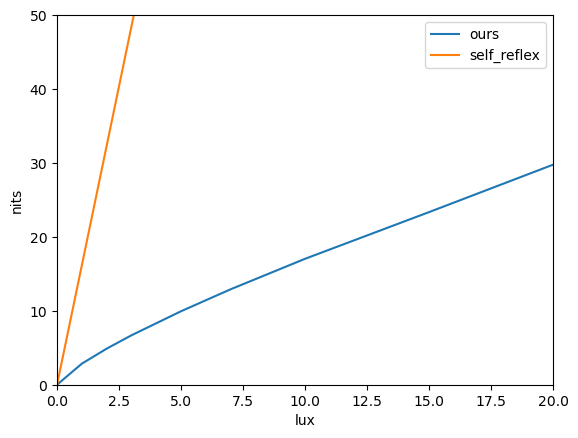

In [8]:
def simulate_brightness_change(
    env_lux: float,
    start_nit: float,
    auto_luxs: Sequence[float],
    auto_nits: Sequence[float],
    self_reflex_ratio: float,  # 0 for black, 1 for white
    /,
    step_lim: tuple[float, float] = (0.95, 1.05),
    lux_change_thresh: tuple[float, float] = (1, 1)
):
    eps = 1e-2
    curr_nit = start_nit
    min_nit, max_nit = min(*auto_nits), max(*auto_nits)
    min_lux, max_lux = min(*auto_luxs), max(*auto_luxs)
    while True:
        prev_nit = curr_nit
        reflex_lux = self_reflex_nit_to_lux(curr_nit) * self_reflex_ratio
        should_lux = linear_map(
            curr_nit,
            auto_nits, auto_luxs
        )
        curr_lux = reflex_lux + env_lux
        if lux_change_thresh[0] * should_lux <= curr_lux <= lux_change_thresh[1] * should_lux:
            break
        curr_nit = linear_map(
            max(min_lux, min(max_lux, curr_lux)),
            auto_luxs, auto_nits,
        )
        curr_nit = max(step_lim[0] * prev_nit, min(step_lim[1] * prev_nit, curr_nit))
        curr_nit = max(min_nit, min(max_nit, curr_nit))
        if abs(curr_nit - prev_nit) < eps:
            break
    return curr_lux, curr_nit

plt.plot(auto_luxs, auto_nits, label='ours')
plt.plot(*make_auto_brightness_map(self_reflex_lux_to_nit), label='self_reflex')
plt.xlim(0, 20)
plt.ylim(0, 50)
plt.xlabel('lux')
plt.ylabel('nits')
plt.legend()
print(simulate_brightness_change(1500, 150, auto_luxs, auto_nits, 0))
print(simulate_brightness_change(500, 150, auto_luxs, auto_nits, 0))
print(simulate_brightness_change(300, 150, auto_luxs, auto_nits, 0))
print(simulate_brightness_change(200, 150, auto_luxs, auto_nits, 0))
print(simulate_brightness_change(100, 150, auto_luxs, auto_nits, 0))
print(simulate_brightness_change(20, 150, auto_luxs, auto_nits, 1))
print(simulate_brightness_change(5, 150, auto_luxs, auto_nits, 1))
print(simulate_brightness_change(5, 150, auto_luxs, auto_nits, 0))
print(simulate_brightness_change(2, 150, auto_luxs, auto_nits, 0))
print(simulate_brightness_change(1, 150, auto_luxs, auto_nits, 1))
print(simulate_brightness_change(1, 150, auto_luxs, auto_nits, 0))
print(simulate_brightness_change(.5, 150, auto_luxs, auto_nits, 1))
print(simulate_brightness_change(.5, 150, auto_luxs, auto_nits, 0))

## Final Answers

### Panel-specific displayconfig

For `config/display/display_id_xxxx.xml`.

#### Screen brightness map

We use original points here since interpolation is guaranteed to be linear.

In [9]:
text = ''
text += '    <screenBrightnessMap interpolation="linear">\n'
text += make_displayconfig_levels(
    list(zip(map(register_to_backlight, panel_registers), panel_nits)),
    'point',
    ['value', 'nits'],
    indent = ' ' * 8
)
text += '    </screenBrightnessMap>\n'
print(text)

    <screenBrightnessMap interpolation="linear">
        <point><value>0.0</value><nits>0.0</nits></point>
        <point><value>0.0004884004884004884</value><nits>1.2270864424056285</nits></point>
        <point><value>0.0009768009768009768</value><nits>2.1330104862470782</nits></point>
        <point><value>0.0014652014652014652</value><nits>2.402433645322013</nits></point>
        <point><value>0.0019536019536019536</value><nits>2.689425199024708</nits></point>
        <point><value>0.0029304029304029304</value><nits>3.316831254323666</nits></point>
        <point><value>0.004884004884004884</value><nits>4.789992625927502</nits></point>
        <point><value>0.009768009768009768</value><nits>9.211771928629664</nits></point>
        <point><value>0.014652014652014652</value><nits>14.488521899711087</nits></point>
        <point><value>0.02197802197802198</value><nits>22.009026599403427</nits></point>
        <point><value>0.03418803418803419</value><nits>33.56933113688369</nits></poi

#### Global HBM parameters

In [10]:
print('Transition point:', register_to_backlight(key_registers[I_SUSTAINABLE_MAX]))
print('Minimum lux:', round(linear_map(key_nits[I_SUSTAINABLE_MAX], auto_nits, auto_luxs)))

Transition point: 0.4998778998778999
Minimum lux: 20000


#### Auto brightness (normal) curve

In [11]:
tmp_luxs, tmp_nits = curve_topoff(auto_luxs, auto_nits, key_nits[I_HBM_MAX])
print(make_displayconfig_levels(
    list(zip(tmp_luxs, map(nit_to_backlight, tmp_nits))),
    'point',
    ['first', 'second'],
    indent = ' ' * 16
))

                <point><first>0</first><second>0.0</second></point>
                <point><first>1</first><second>0.0021978021978021965</second></point>
                <point><first>2</first><second>0.004980564296847345</second></point>
                <point><first>3</first><second>0.00697571391286013</second></point>
                <point><first>5</first><second>0.010442431558228086</second></point>
                <point><first>7</first><second>0.013191701604031391</second></point>
                <point><first>10</first><second>0.017131694104678054</second></point>
                <point><first>15</first><second>0.02339495708414827</second></point>
                <point><first>20</first><second>0.030170830860261486</second></point>
                <point><first>30</first><second>0.041520206918307885</second></point>
                <point><first>50</first><second>0.04636494717805806</second></point>
                <point><first>70</first><second>0.049074631382092955</second></

#### Auto brightness (doze/AOD) curve

In [12]:
max_doze_nits = backlight_to_nit(0.04)
doze_ratio = 0.6
tmp_luxs, tmp_nits = curve_topoff(auto_luxs, auto_nits, key_nits[I_HBM_MAX])
tmp_luxs, tmp_nits = curve_topoff(tmp_luxs, [ v * doze_ratio for v in tmp_nits ], max_doze_nits, keep_tail=True)
print(make_displayconfig_levels(
    list(zip(map(round, tmp_luxs), map(nit_to_backlight, tmp_nits))),
    'point',
    ['first', 'second'],
    indent = ' ' * 16
))

                <point><first>0</first><second>0.0</second></point>
                <point><first>1</first><second>0.0007475437861444705</second></point>
                <point><first>2</first><second>0.0023226201543539416</second></point>
                <point><first>3</first><second>0.0038499583469403407</second></point>
                <point><first>5</first><second>0.006181018773458049</second></point>
                <point><first>7</first><second>0.008149530945807611</second></point>
                <point><first>10</first><second>0.010701585237824704</second></point>
                <point><first>15</first><second>0.014209422645572822</second></point>
                <point><first>20</first><second>0.017935843214026373</second></point>
                <point><first>30</first><second>0.024080891279174347</second></point>
                <point><first>50</first><second>0.02677361645729602</second></point>
                <point><first>70</first><second>0.028282404244382473</secon

#### Even-dimmer curve

Due to the defect that fingerprint pressing mode either disables even-dimmer dimming layer
or be affected by it (impacting recognition success rate),
we want to keep software dimming minimal. Hence we:

- Make sure that brightness values down to the USABLE_MIN does not involve any software dimming.
- Base any lower brightness values on the USABLE_MIN hardware brightness and achieve them using software dimming.

The two inteference behaviors are configured by kernel function `is_skip_pcc` in `techpack/display/oplus/oplus_onscreenfingerprint.c`.

In [13]:
evendimmer_target_nit = 1.5
evendimmer_target_eqregister = key_registers[I_USABLE_MIN] * (evendimmer_target_nit / key_nits[I_USABLE_MIN])
assert evendimmer_target_nit < key_nits[I_USABLE_MIN], 'evenDimmer target min nits should be lower than hardware value'

print('Target minimum nit:', evendimmer_target_nit)
print('Minimum usable nit:', key_nits[I_USABLE_MIN])
print('Minimum stock nit:', key_nits[I_STOCK_MIN])

evendimmer_levels = []  # Order: [brightness, backlight, nits]
# Target nit point
evendimmer_levels.append([
    register_to_backlight(evendimmer_target_eqregister),
    register_to_backlight(key_registers[I_USABLE_MIN]),
    evendimmer_target_nit
])
# Original points
evendimmer_transition_register = -1
for register, nit in zip(panel_registers, panel_nits):
    if register < key_registers[I_USABLE_MIN]: continue
    if math.isclose(register, key_registers[I_USABLE_MIN]):
        # Make the distance between target nit point and transition point adequately large, so that the
        #   evenDimmer range will take up a reasonably larger space on the brightness slider.
        # This delta shall not exceed 0.5, otherwise the register value will be rounded up rather than down.
        register += 0.45
    if evendimmer_transition_register < 0:
        evendimmer_transition_register = register
    evendimmer_levels.append([
        register_to_backlight(register),
        register_to_backlight(register),
        nit
    ])

text = ''
text += '        <brightnessMapping>\n'
# Target value point
text += make_displayconfig_levels(
    evendimmer_levels,
    'brightnessPoint',
    ['brightness', 'backlight', 'nits'],
    indent=' ' * 12
)
text += '        </brightnessMapping>\n'
print(text)
print('Transition point:', register_to_backlight(evendimmer_transition_register))

Target minimum nit: 1.5
Minimum usable nit: 2.1330104862470782
Minimum stock nit: 2.8462767128494475
        <brightnessMapping>
            <brightnessPoint><brightness>0.0006869171411245199</brightness><backlight>0.0009768009768009768</backlight><nits>1.5</nits></brightnessPoint>
            <brightnessPoint><brightness>0.0010866910866910867</brightness><backlight>0.0010866910866910867</backlight><nits>2.1330104862470782</nits></brightnessPoint>
            <brightnessPoint><brightness>0.0014652014652014652</brightness><backlight>0.0014652014652014652</backlight><nits>2.402433645322013</nits></brightnessPoint>
            <brightnessPoint><brightness>0.0019536019536019536</brightness><backlight>0.0019536019536019536</backlight><nits>2.689425199024708</nits></brightnessPoint>
            <brightnessPoint><brightness>0.0029304029304029304</brightness><backlight>0.0029304029304029304</backlight><nits>3.316831254323666</nits></brightnessPoint>
            <brightnessPoint><brightness>0.0

### Legacy config

For `overlay/OPlusFrameworksResTarget/res/values/config.xml`.

For configurations that exist in both panel-specific displayconfig and legacy config,
the panel-specific displayconfig will take precedence.
The legacy config will be used as a fail-safe fallback.

#### Screen brightness map

Use a custom list of lv255s, since (1) we do not know the interpolation method and
(2) lv255 values can only be integers between 1 and 255, therefore unable to accurately represent the original curve.

In [14]:
aosp_lv255s = [
    1, 2, 3, 4, 6, 8, 12, 16, 24, 32, 48, 64, 96, 128,
    160, 192, 224, 255
]
print(make_xml_array([ round(item) for item in aosp_lv255s ], indent=' '*8))

        <item>1</item>
        <item>2</item>
        <item>3</item>
        <item>4</item>
        <item>6</item>
        <item>8</item>
        <item>12</item>
        <item>16</item>
        <item>24</item>
        <item>32</item>
        <item>48</item>
        <item>64</item>
        <item>96</item>
        <item>128</item>
        <item>160</item>
        <item>192</item>
        <item>224</item>
        <item>255</item>



In [15]:
print(make_xml_array([
    register_to_nit(lv255_to_register(v))
    for v in aosp_lv255s
], indent=' '*8))

        <item>0.0</item>
        <item>4.075886350814422</item>
        <item>7.4970268053376845</item>
        <item>11.419073835824157</item>
        <item>19.655167844972162</item>
        <item>27.29308705925169</item>
        <item>41.56717961183078</item>
        <item>55.56689161590918</item>
        <item>85.3760610340473</item>
        <item>115.03901781219972</item>
        <item>172.64973466724064</item>
        <item>230.20860484006081</item>
        <item>355.487840467214</item>
        <item>484.6305699378903</item>
        <item>575.0529716321261</item>
        <item>679.3453251973676</item>
        <item>721.3027901055128</item>
        <item>727.41437</item>



#### Default properties

In [16]:
print('Min:', register_to_backlight(key_registers[I_USABLE_MIN]))
print('Dim:', register_to_backlight(key_registers[I_STOCK_MIN]))
print('Doze:', nit_to_backlight(max_doze_nits))  # Maximum allowed brightness of AOD
print('Default:', nit_to_backlight(100))
print('Max:', register_to_backlight(key_registers[I_HBM_MAX]))  # Still applies when panel-specific HBM is on, so must be HBM_MAX.
print('Doze scale factor:', str(round(100 * doze_ratio)) + '%')

Min: 0.0009768009768009768
Dim: 0.002197802197802198
Doze: 0.04
Default: 0.10534772201081638
Max: 1.0
Doze scale factor: 60%


#### Auto brightness curve

In [17]:
tmp_luxs, tmp_nits = curve_topoff(auto_luxs, auto_nits, key_nits[I_HBM_MAX])
print(make_xml_array([ round(item) for item in tmp_luxs[1:] ], indent=' '*8))

        <item>1</item>
        <item>2</item>
        <item>3</item>
        <item>5</item>
        <item>7</item>
        <item>10</item>
        <item>15</item>
        <item>20</item>
        <item>30</item>
        <item>50</item>
        <item>70</item>
        <item>100</item>
        <item>150</item>
        <item>200</item>
        <item>300</item>
        <item>500</item>
        <item>700</item>
        <item>1000</item>
        <item>1500</item>
        <item>2000</item>
        <item>3000</item>
        <item>5000</item>
        <item>7000</item>
        <item>10000</item>
        <item>15000</item>
        <item>20000</item>
        <item>30000</item>
        <item>50000</item>



In [18]:
print(make_xml_array([ item for item in tmp_nits ], indent=' '*8))

        <item>0.0</item>
        <item>2.8462767128494466</item>
        <item>4.877413589527718</item>
        <item>6.683740873673545</item>
        <item>9.94042704805555</item>
        <item>12.91077842550784</item>
        <item>17.034034093137876</item>
        <item>23.35056508887644</item>
        <item>29.765887449910903</item>
        <item>39.99999999900983</item>
        <item>44.24907070145376</item>
        <item>46.62991002156078</item>
        <item>49.99486274237591</item>
        <item>54.32736446036781</item>
        <item>60.10578650040854</item>
        <item>76.5723868177431</item>
        <item>100.05594359893647</item>
        <item>115.99959226662494</item>
        <item>134.52296975868038</item>
        <item>159.99406372967147</item>
        <item>180.94659161257735</item>
        <item>215.21823826556837</item>
        <item>267.78236101062737</item>
        <item>309.2380344510718</item>
        <item>360.2078823982697</item>
        <item>427.9969616024057